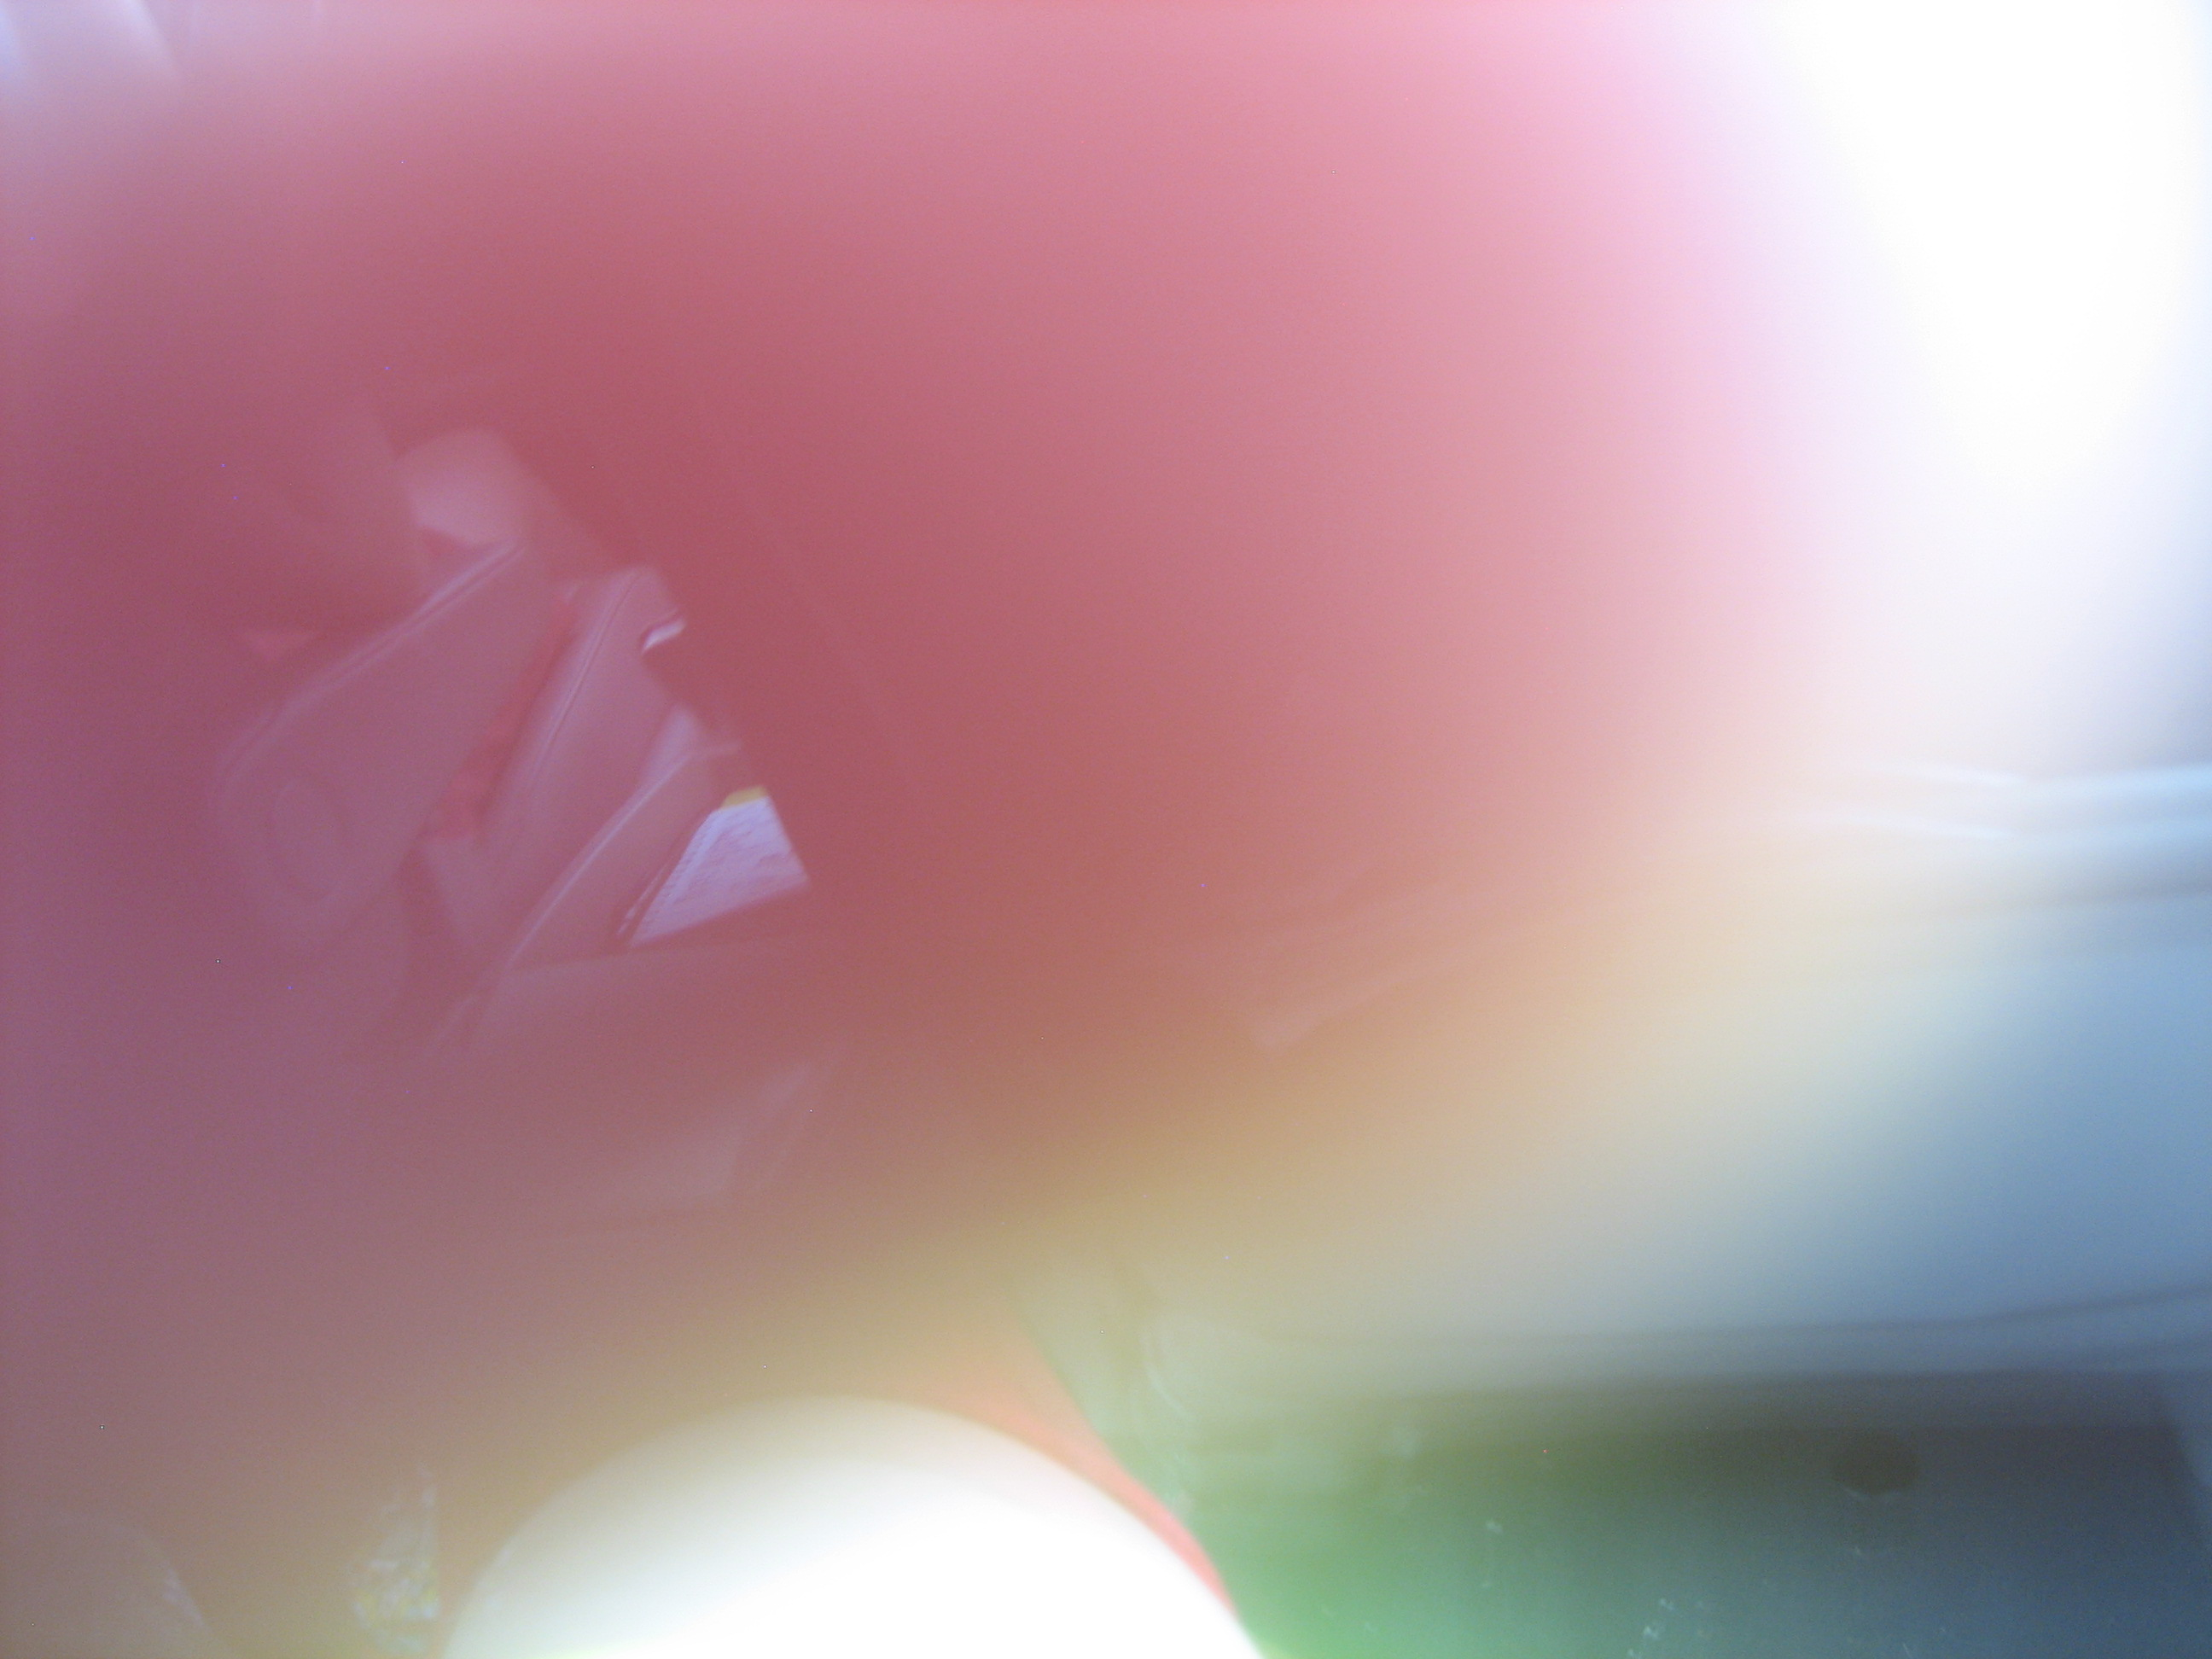

9.670200584702805
29.178610115440428
46.22059269538968


AttributeError: module 'cv2' has no attribute 'saliency'

In [ ]:
from fx import *
for p in [
    '/mnt/4C74F47B74F468DA/Pictures/IMG_0822-2005-01-04 015604.JPG', # blurry finger
    '/mnt/4C74F47B74F468DA/Pictures/IMG_0823-2005-01-04 015606.JPG', # blurry red nothing
    'labeled_pics/daughter.JPG'
]:
    def sharpness_score(img):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return cv2.Laplacian(gray, cv2.CV_64F).var()

    def colorfulness(img):
        (B, G, R) = cv2.split(img.astype("float"))
        rg = np.abs(R - G)
        yb = np.abs(0.5*(R + G) - B)
        return np.sqrt(np.var(rg) + np.var(yb))
    
    def contrast(img):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return gray.std()
    
    def saliency(img):  #require opencv-contrib ? what is saliency
        saliency = cv2.saliency.StaticSaliencySpectralResidual_create()
        (success, saliencyMap) = saliency.computeSaliency(img)
        return saliencyMap.mean()


    show(p)
    pipe(p,cv2.imread,sharpness_score,print)
    pipe(p,cv2.imread,colorfulness,print)
    pipe(p,cv2.imread,contrast,print)
    pipe(p,cv2.imread,saliency,print)


In [ ]:

import cv2
import numpy as np




def normalize(x, min_val, max_val):
    if max_val == min_val:
        return 0
    return (x - min_val) / (max_val - min_val)

score = (
    0.3 * normalize(sharpness) +
    0.2 * normalize(colorfulness) +
    0.2 * normalize(contrast) +
    0.3 * normalize(saliency)
)
# https://chatgpt.com/share/69c6c09f-8e88-8328-8f35-5c64faf04bac
# https://chatgpt.com/c/69c92499-ffc0-832c-831f-f0507146e316
# https://github.com/openai/CLIP




